**Checking GPU**

In [9]:
import torch
print(torch.cuda.is_available())
print(torch.cuda.get_device_name(0))

True
Tesla T4


**Clone repo and install dependencies**

In [10]:
!git clone https://github.com/areesha900/DM_project.git
%cd DM_project
!pip install munkres pyyaml scikit-learn opencv-python -q

Cloning into 'DM_project'...
remote: Enumerating objects: 54, done.
remote: Counting objects: 100% (54/54), done.
remote: Compressing objects: 100% (48/48), done.
remote: Total 54 (delta 19), reused 0 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (54/54), 1.18 MiB | 4.83 MiB/s, done.
Resolving deltas: 100% (19/19), done.
/kaggle/working/DM_project/DM_project


**Fixing dataset path**

In [11]:
# Read current config
with open('config/config.yaml', 'r') as f:
    config = f.read()

print("Current config:")
print(config)

Current config:
# general
seed: 42
workers: 2
dataset_dir: "~/datasets"

# train options
batch_size: 256
image_size: 32
start_epoch: 0
epochs: 100
dataset: "CIFAR-100" # CIFAR-10 / CIFAR-100 / STL-10 / ImageNet-10 / ImageNet-dogs / tiny-ImageNet

# model options
resnet: "ResNet18" # ResNet18 / ResNet34 / ResNet50
feature_dim: 128
model_path: "save/CIFAR-100"
reload: False

# loss options
sigma: 0.5 # CIFAR-100: 0.5, other: 1
learning_rate: 0.0003
weight_decay: 0.
instance_temperature: 0.5
cluster_temperature: 1.0



**Update dataset path**

In [12]:
# Fix the dataset path for Kaggle environment
config_updated = config.replace('~/datasets', '/kaggle/working/datasets')

with open('config/config.yaml', 'w') as f:
    f.write(config_updated)

print("Updated config:")
print(config_updated)

Updated config:
# general
seed: 42
workers: 2
dataset_dir: "/kaggle/working/datasets"

# train options
batch_size: 256
image_size: 32
start_epoch: 0
epochs: 100
dataset: "CIFAR-100" # CIFAR-10 / CIFAR-100 / STL-10 / ImageNet-10 / ImageNet-dogs / tiny-ImageNet

# model options
resnet: "ResNet18" # ResNet18 / ResNet34 / ResNet50
feature_dim: 128
model_path: "save/CIFAR-100"
reload: False

# loss options
sigma: 0.5 # CIFAR-100: 0.5, other: 1
learning_rate: 0.0003
weight_decay: 0.
instance_temperature: 0.5
cluster_temperature: 1.0



**EDA**

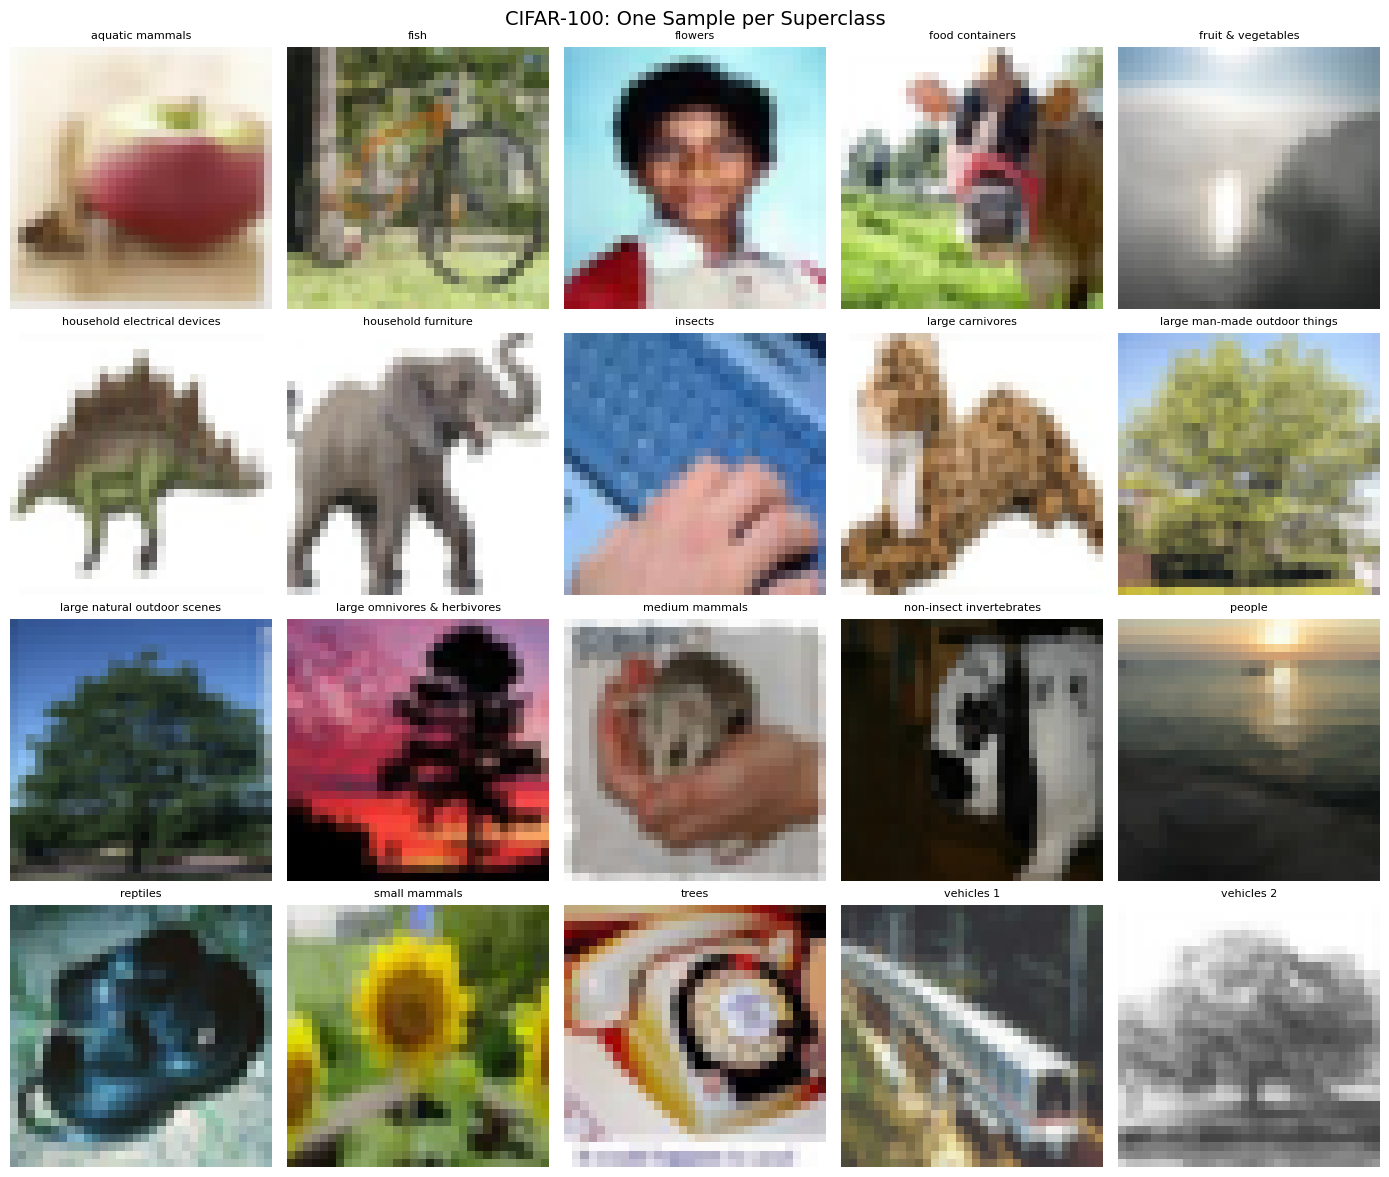

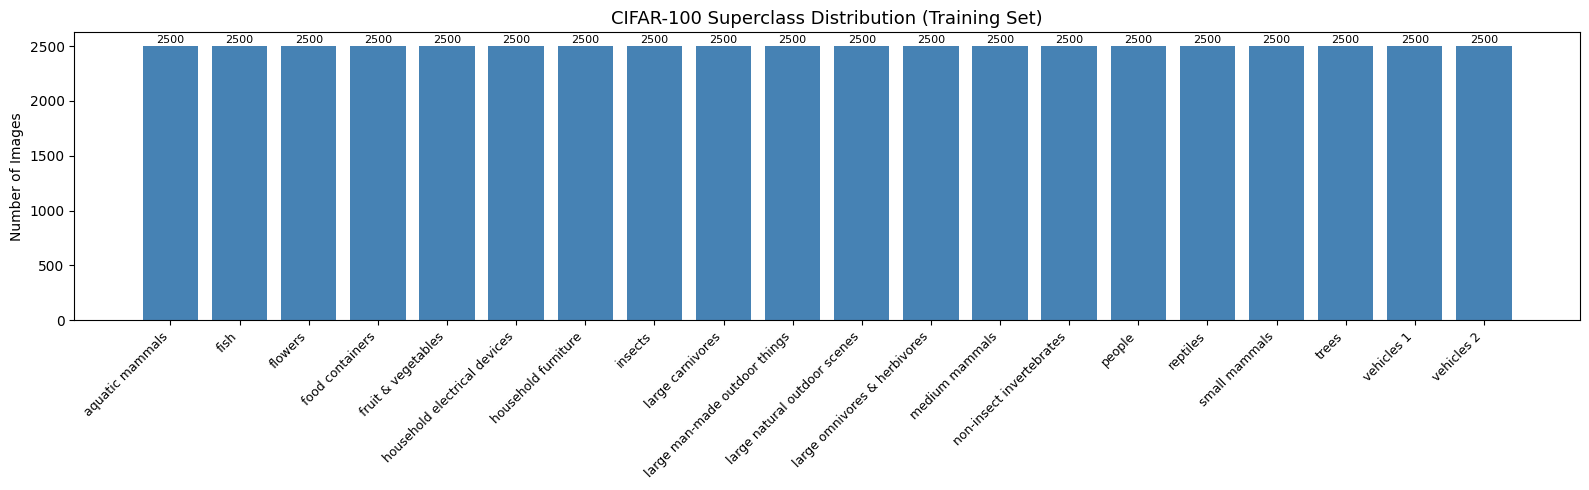

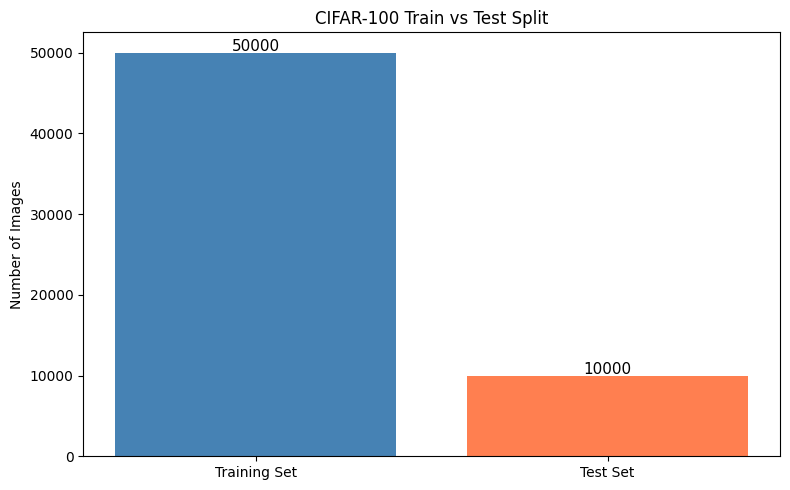

         CIFAR-100 Dataset Summary
  Training images     : 50000
  Test images         : 10000
  Total images        : 60000
  Superclasses        : 20
  Fine-grained classes: 100
  Images/superclass   : 3000
  Images/fine class   : 600
  Image size          : 32 x 32 x 3


In [13]:
import torchvision
import matplotlib.pyplot as plt
import numpy as np

# Download CIFAR-100
train_dataset = torchvision.datasets.CIFAR100(
    root='/kaggle/working/datasets',
    train=True,
    download=True
)
test_dataset = torchvision.datasets.CIFAR100(
    root='/kaggle/working/datasets',
    train=False,
    download=True
)

superclasses = [
    'aquatic mammals', 'fish', 'flowers', 'food containers',
    'fruit & vegetables', 'household electrical devices',
    'household furniture', 'insects', 'large carnivores',
    'large man-made outdoor things', 'large natural outdoor scenes',
    'large omnivores & herbivores', 'medium mammals',
    'non-insect invertebrates', 'people', 'reptiles',
    'small mammals', 'trees', 'vehicles 1', 'vehicles 2'
]

# --- Plot 1: Sample images (one per superclass) ---
fig, axes = plt.subplots(4, 5, figsize=(14, 12))
shown = {}
for img, label in train_dataset:
    sc = label // 5
    if sc not in shown:
        shown[sc] = (img, label)
    if len(shown) == 20:
        break

for i, ax in enumerate(axes.flat):
    img, label = shown[i]
    ax.imshow(img)
    ax.set_title(superclasses[i], fontsize=8)
    ax.axis('off')
plt.suptitle('CIFAR-100: One Sample per Superclass', fontsize=14)
plt.tight_layout()
plt.savefig('eda_samples.png', dpi=150)
plt.show()

# --- Plot 2: Superclass distribution ---
targets = np.array(train_dataset.targets)
superclass_labels = targets // 5
counts = [np.sum(superclass_labels == i) for i in range(20)]

plt.figure(figsize=(16, 5))
bars = plt.bar(range(20), counts, color='steelblue')
plt.xticks(range(20), superclasses, rotation=45, ha='right', fontsize=9)
plt.title('CIFAR-100 Superclass Distribution (Training Set)', fontsize=13)
plt.ylabel('Number of Images')
for bar, count in zip(bars, counts):
    plt.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 30,
             str(count), ha='center', fontsize=8)
plt.tight_layout()
plt.savefig('eda_distribution.png', dpi=150)
plt.show()

# --- Plot 3: Train vs Test split ---
plt.figure(figsize=(8, 5))
plt.bar(['Training Set', 'Test Set'], [len(train_dataset), len(test_dataset)],
        color=['steelblue', 'coral'])
plt.title('CIFAR-100 Train vs Test Split')
plt.ylabel('Number of Images')
for i, v in enumerate([len(train_dataset), len(test_dataset)]):
    plt.text(i, v + 200, str(v), ha='center', fontsize=11)
plt.tight_layout()
plt.savefig('eda_split.png', dpi=150)
plt.show()

# --- Summary ---
print("=" * 45)
print("         CIFAR-100 Dataset Summary")
print("=" * 45)
print(f"  Training images     : {len(train_dataset)}")
print(f"  Test images         : {len(test_dataset)}")
print(f"  Total images        : {len(train_dataset) + len(test_dataset)}")
print(f"  Superclasses        : 20")
print(f"  Fine-grained classes: 100")
print(f"  Images/superclass   : {(len(train_dataset) + len(test_dataset)) // 20}")
print(f"  Images/fine class   : {(len(train_dataset) + len(test_dataset)) // 100}")
print(f"  Image size          : 32 x 32 x 3")
print("=" * 45)

**Train**

In [14]:
!python train.py

Step [0/234]	 loss_instance: 12.398917198181152	 loss_cluster: 11.124205589294434
Step [50/234]	 loss_instance: 11.379070281982422	 loss_cluster: 10.226755142211914
Step [100/234]	 loss_instance: 11.24414348602295	 loss_cluster: 10.09776782989502
Step [150/234]	 loss_instance: 11.15192985534668	 loss_cluster: 10.092381477355957
Step [200/234]	 loss_instance: 11.001511573791504	 loss_cluster: 9.98330307006836
Epoch [0/100]	 Loss: 16.333471876943214
Step [0/234]	 loss_instance: 10.953896522521973	 loss_cluster: 9.973674774169922
Step [50/234]	 loss_instance: 10.953312873840332	 loss_cluster: 9.95724105834961
Step [100/234]	 loss_instance: 10.807555198669434	 loss_cluster: 9.83765697479248
Step [150/234]	 loss_instance: 10.835443496704102	 loss_cluster: 9.749496459960938
Step [200/234]	 loss_instance: 10.83333969116211	 loss_cluster: 9.866755485534668
Epoch [1/100]	 Loss: 15.862577234577929
Step [0/234]	 loss_instance: 10.851993560791016	 loss_cluster: 9.851114273071289
Step [50/234]	 los

**Evaluate**

In [15]:
!python cluster.py --start_epoch 100

### Creating features from model ###
Step [0/30]	 Computing features...
Step [20/30]	 Computing features...
Features shape (60000,)
NMI = 0.1980 ARI = 0.0910 F = 0.1398 ACC = 0.2447


**Plot Loss Curve**

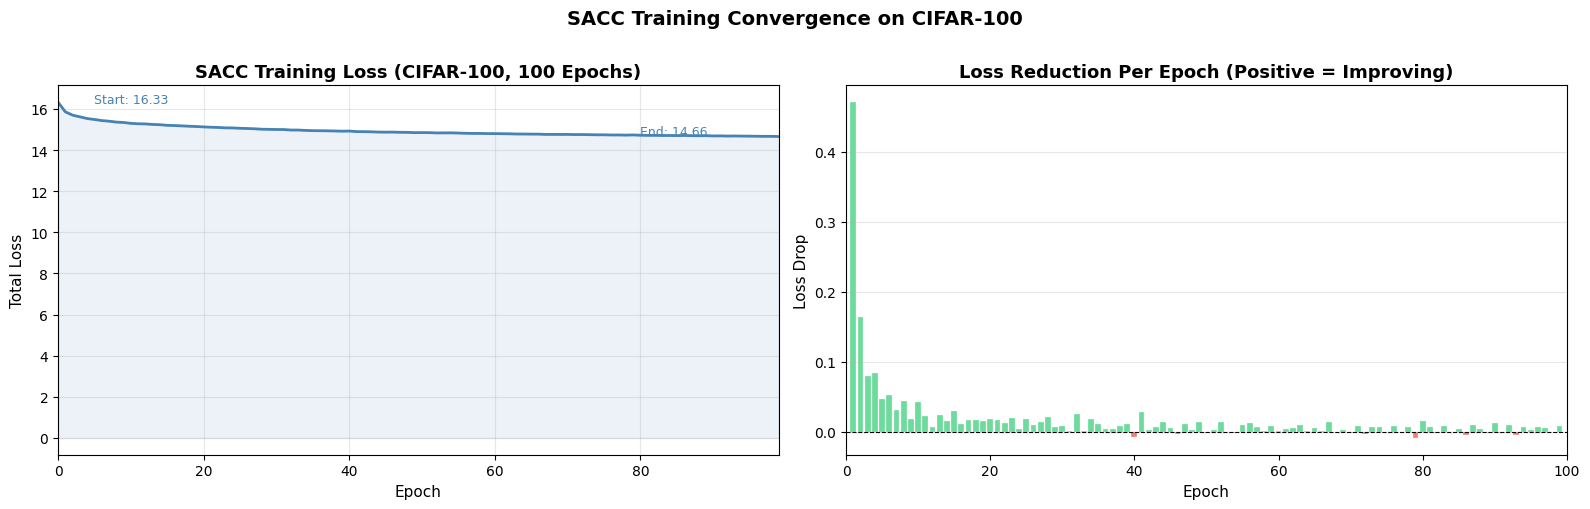

Total loss drop: 1.6729 (16.3335 → 14.6606)
Average drop/epoch: 0.0167
Epochs with improvement: 81/99


In [17]:
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

losses = [
    16.333471876943214, 15.862577234577929, 15.698885440826416,
    15.619132755149124, 15.535632679605076, 15.48962897928352,
    15.437186526437092, 15.406232316269834, 15.362312744825314,
    15.343911060920128, 15.30161251165928, 15.280082364367624,
    15.273103114886162, 15.248971890180538, 15.233953080625616,
    15.205027784037794, 15.194388837895842, 15.178100524804531,
    15.161399026202341, 15.146793777107174, 15.128900568709414,
    15.112642597948383, 15.101120973244692, 15.08189527805035,
    15.077835148216312, 15.060280298575377, 15.05093655626998,
    15.03697697729127, 15.016062508281479, 15.008989668300009,
    15.001660469250801, 15.00019027840378, 14.975767041882898,
    14.975135257101467, 14.957063634171446, 14.94593575469449,
    14.942164971278263, 14.938133997794909, 14.930224964761326,
    14.91955411943615, 14.926892154237144, 14.89946331937089,
    14.89679437621027, 14.890405895363571, 14.877296455904968,
    14.872820100213728, 14.875686657734406, 14.865044777209942,
    14.862832754086226, 14.849488731123444, 14.851520403837545,
    14.84952362989768, 14.835913124247494, 14.836888382577488,
    14.839357306814602, 14.829302722572262, 14.817622180677887,
    14.811703180655455, 14.810706745864998, 14.803287734333267,
    14.802097593617235, 14.797846741146511, 14.792633419362907,
    14.783020048059969, 14.782335171332726, 14.777639442019993,
    14.776667452266073, 14.7625474073948, 14.763156112442669,
    14.761534059149588, 14.763372580210367, 14.75473232758351,
    14.757585166865944, 14.750573325360943, 14.743976817171799,
    14.74405581726987, 14.735395981715275, 14.735543397756723,
    14.728834788004557, 14.73794470485459, 14.722361246744791,
    14.715253120813614, 14.717491484095907, 14.709061288426065,
    14.709823722513313, 14.706353900779007, 14.71076520284017,
    14.701839125054514, 14.698665655576265, 14.7014358675378,
    14.689645164033287, 14.691607626075418, 14.682759904453897,
    14.68723008571527, 14.681228572486813, 14.67874478071164,
    14.672877678504356, 14.668384564228546, 14.66893797246819,
    14.660556491623577
]

epochs = list(range(len(losses)))

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# --- Plot 1: Full loss curve ---
axes[0].plot(epochs, losses, color='steelblue', linewidth=2)
axes[0].fill_between(epochs, losses, alpha=0.1, color='steelblue')
axes[0].set_title('SACC Training Loss (CIFAR-100, 100 Epochs)', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Epoch', fontsize=11)
axes[0].set_ylabel('Total Loss', fontsize=11)
axes[0].set_xlim(0, 99)
axes[0].grid(True, alpha=0.3)
axes[0].annotate(f'Start: {losses[0]:.2f}', xy=(0, losses[0]),
                 xytext=(5, losses[0]-0.05), fontsize=9, color='steelblue')
axes[0].annotate(f'End: {losses[-1]:.2f}', xy=(99, losses[-1]),
                 xytext=(80, losses[-1]+0.05), fontsize=9, color='steelblue')

# --- Plot 2: Loss reduction per epoch (smoothed) ---
deltas = [losses[i] - losses[i+1] for i in range(len(losses)-1)]
axes[1].bar(range(1, len(losses)), deltas, color=['#2ecc71' if d > 0 else '#e74c3c' for d in deltas],
            alpha=0.7, edgecolor='white', linewidth=0.3)
axes[1].axhline(0, color='black', linewidth=0.8, linestyle='--')
axes[1].set_title('Loss Reduction Per Epoch (Positive = Improving)', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Epoch', fontsize=11)
axes[1].set_ylabel('Loss Drop', fontsize=11)
axes[1].set_xlim(0, 100)
axes[1].grid(True, alpha=0.3, axis='y')

plt.suptitle('SACC Training Convergence on CIFAR-100', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('loss_curve.png', dpi=150, bbox_inches='tight')
plt.show()

total_drop = losses[0] - losses[-1]
print(f"Total loss drop: {total_drop:.4f} ({losses[0]:.4f} → {losses[-1]:.4f})")
print(f"Average drop/epoch: {total_drop/len(losses):.4f}")
print(f"Epochs with improvement: {sum(1 for d in deltas if d > 0)}/{len(deltas)}")

**FULL EDA**

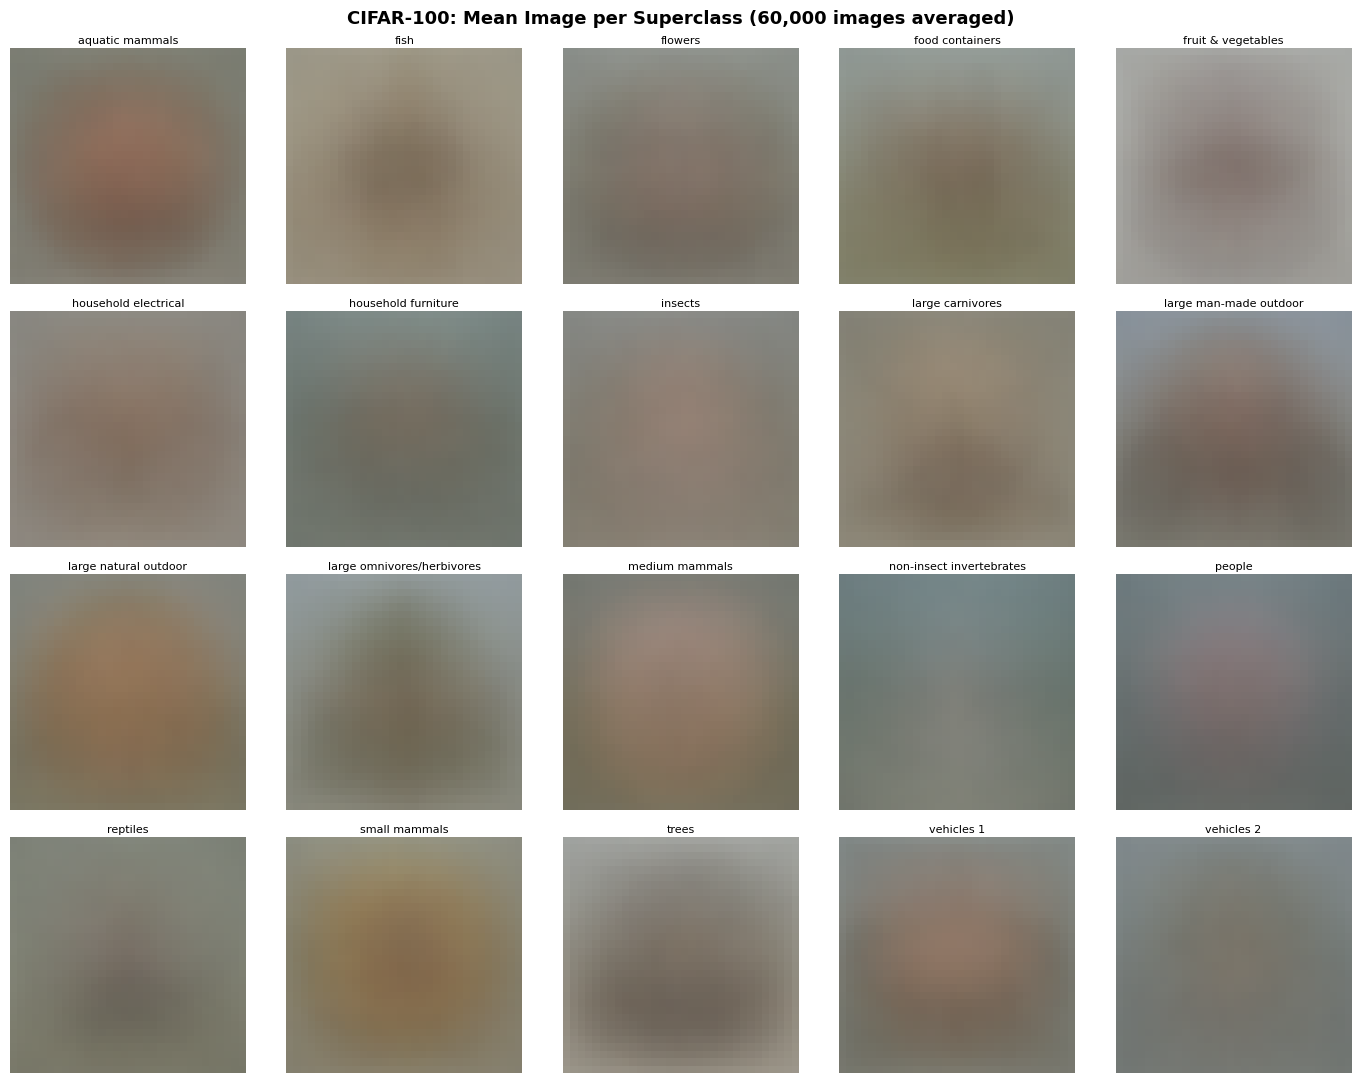

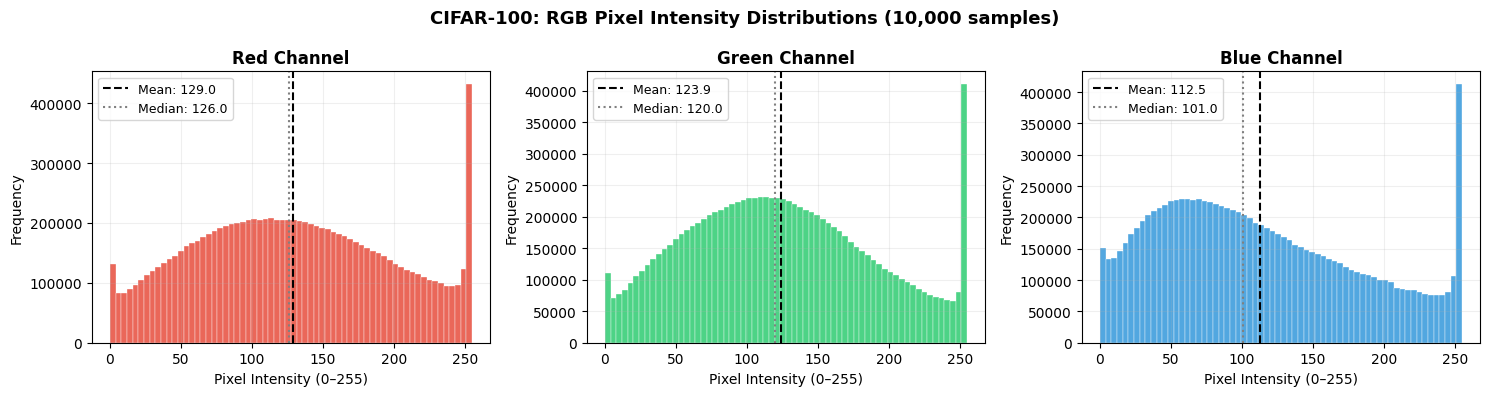

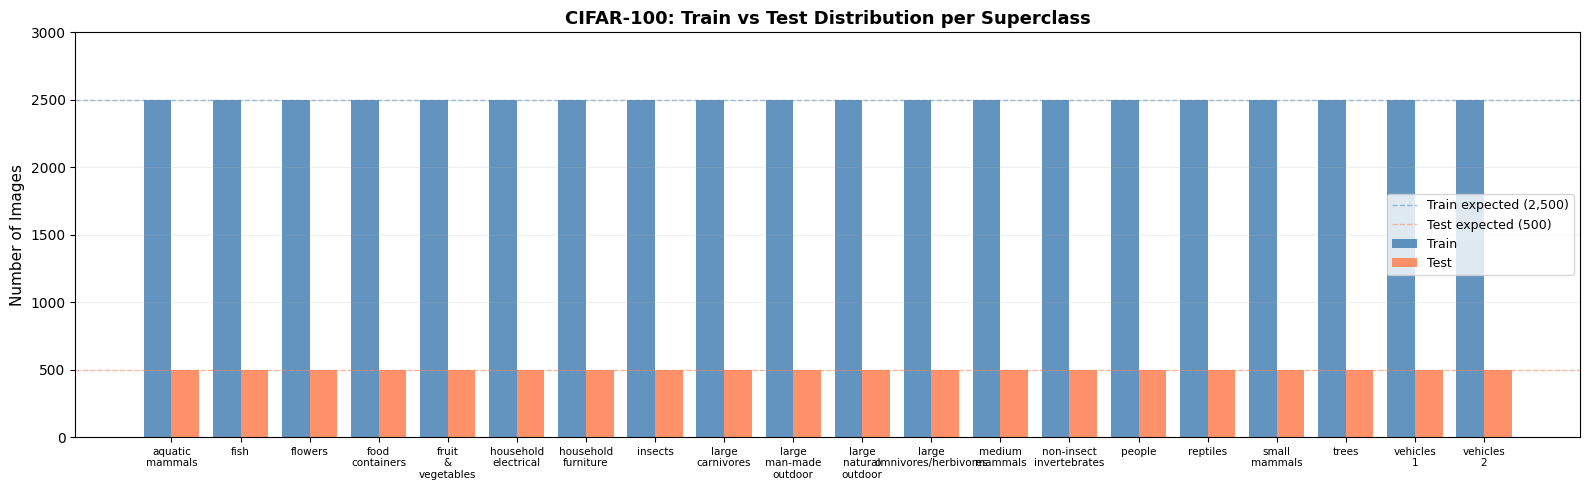

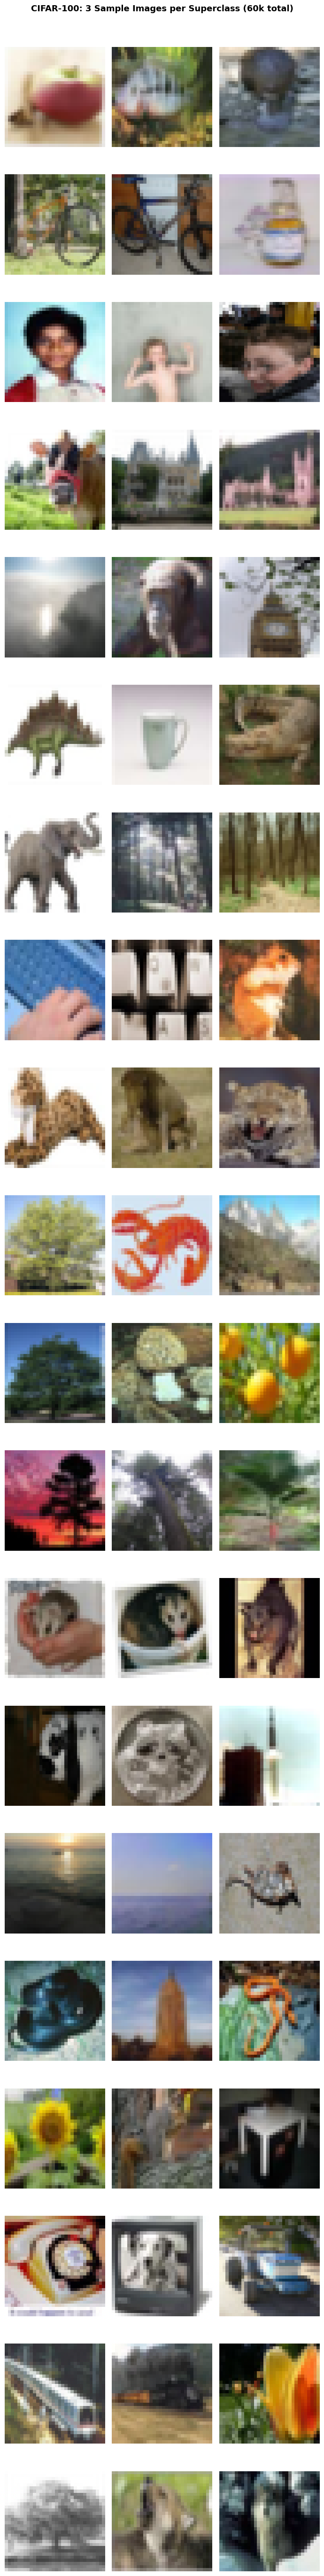

        CIFAR-100 Full Dataset Summary
  Total images         : 60,000
  Train images         : 50,000
  Test images          : 10,000
  Superclasses (used)  : 20
  Fine-grained classes : 100
  Images/superclass    : 3,000
  Image size           : 32 × 32 × 3
  Mean (R, G, B)       : 129.38, 124.11, 112.48
  Std  (R, G, B)       : 68.21, 65.43, 70.46


In [18]:
import torchvision
import matplotlib.pyplot as plt
import numpy as np
from collections import Counter

# Load CIFAR-100
train_data = torchvision.datasets.CIFAR100(root='/kaggle/working/datasets', train=True,  download=True)
test_data  = torchvision.datasets.CIFAR100(root='/kaggle/working/datasets', train=False, download=True)

all_images = np.concatenate([train_data.data, test_data.data], axis=0)
all_labels = train_data.targets + test_data.targets
fine_labels = train_data.classes

superclasses = [
    'aquatic mammals', 'fish', 'flowers', 'food containers',
    'fruit & vegetables', 'household electrical', 'household furniture',
    'insects', 'large carnivores', 'large man-made outdoor',
    'large natural outdoor', 'large omnivores/herbivores',
    'medium mammals', 'non-insect invertebrates', 'people',
    'reptiles', 'small mammals', 'trees', 'vehicles 1', 'vehicles 2'
]
super_labels = [l // 5 for l in all_labels]


# Plot 1: Mean image per superclass
fig, axes = plt.subplots(4, 5, figsize=(14, 11))
for idx, ax in enumerate(axes.flat):
    idxs = [i for i, s in enumerate(super_labels) if s == idx]
    mean_img = all_images[idxs].mean(axis=0).astype(np.uint8)
    ax.imshow(mean_img)
    ax.set_title(superclasses[idx], fontsize=8, pad=3)
    ax.axis('off')
plt.suptitle('CIFAR-100: Mean Image per Superclass (60,000 images averaged)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('eda_mean_images.png', dpi=150, bbox_inches='tight')
plt.show()


# Plot 2: RGB channel intensity distributions
sample = all_images[:10000]
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
channels = ['Red', 'Green', 'Blue']
colors   = ['#e74c3c', '#2ecc71', '#3498db']
for i, (ch, col) in enumerate(zip(channels, colors)):
    data_ch = sample[:, :, :, i].flatten()
    axes[i].hist(data_ch, bins=64, color=col, alpha=0.85, edgecolor='white', linewidth=0.3)
    axes[i].set_title(f'{ch} Channel', fontsize=12, fontweight='bold')
    axes[i].set_xlabel('Pixel Intensity (0–255)', fontsize=10)
    axes[i].set_ylabel('Frequency', fontsize=10)
    axes[i].axvline(data_ch.mean(), color='black', linestyle='--', linewidth=1.5,
                    label=f'Mean: {data_ch.mean():.1f}')
    axes[i].axvline(np.median(data_ch), color='gray', linestyle=':', linewidth=1.5,
                    label=f'Median: {np.median(data_ch):.1f}')
    axes[i].legend(fontsize=9)
    axes[i].grid(True, alpha=0.2)
plt.suptitle('CIFAR-100: RGB Pixel Intensity Distributions (10,000 samples)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('eda_rgb_distributions.png', dpi=150, bbox_inches='tight')
plt.show()


# Plot 3: Superclass balance (train vs test)
train_super = [l // 5 for l in train_data.targets]
test_super  = [l // 5 for l in test_data.targets]
train_counts = [train_super.count(i) for i in range(20)]
test_counts  = [test_super.count(i) for i in range(20)]

x = np.arange(20)
fig, ax = plt.subplots(figsize=(16, 5))
bars1 = ax.bar(x - 0.2, train_counts, 0.4, label='Train', color='steelblue', alpha=0.85)
bars2 = ax.bar(x + 0.2, test_counts,  0.4, label='Test',  color='coral',     alpha=0.85)
ax.set_xticks(x)
ax.set_xticklabels([s.replace(' ', '\n') for s in superclasses], fontsize=7.5)
ax.set_ylabel('Number of Images', fontsize=11)
ax.set_title('CIFAR-100: Train vs Test Distribution per Superclass', fontsize=13, fontweight='bold')
ax.axhline(2500, color='steelblue', linestyle='--', linewidth=1, alpha=0.5, label='Train expected (2,500)')
ax.axhline(500,  color='coral',     linestyle='--', linewidth=1, alpha=0.5, label='Test expected (500)')
ax.legend(fontsize=9)
ax.set_ylim(0, 3000)
ax.grid(True, alpha=0.2, axis='y')
plt.tight_layout()
plt.savefig('eda_train_test_balance.png', dpi=150, bbox_inches='tight')
plt.show()

# Plot 4: Sample images grid (3 per superclass)
fig, axes = plt.subplots(20, 3, figsize=(7, 55))
for row in range(20):
    idxs = [i for i, s in enumerate(super_labels) if s == row][:3]
    for col, img_idx in enumerate(idxs):
        axes[row, col].imshow(all_images[img_idx])
        axes[row, col].axis('off')
    axes[row, 0].set_ylabel(superclasses[row], fontsize=8, rotation=0, labelpad=75, va='center')
plt.suptitle('CIFAR-100: 3 Sample Images per Superclass (60k total)', fontsize=13, fontweight='bold', y=1.002)
plt.tight_layout()
plt.savefig('eda_samples_grid.png', dpi=150, bbox_inches='tight')
plt.show()


# Summary stats
mean_ch = all_images.mean(axis=(0,1,2))
std_ch  = all_images.std(axis=(0,1,2))
print("=" * 50)
print("        CIFAR-100 Full Dataset Summary")
print("=" * 50)
print(f"  Total images         : {len(all_images):,}")
print(f"  Train images         : {len(train_data):,}")
print(f"  Test images          : {len(test_data):,}")
print(f"  Superclasses (used)  : 20")
print(f"  Fine-grained classes : 100")
print(f"  Images/superclass    : {len(all_images)//20:,}")
print(f"  Image size           : 32 × 32 × 3")
print(f"  Mean (R, G, B)       : {mean_ch[0]:.2f}, {mean_ch[1]:.2f}, {mean_ch[2]:.2f}")
print(f"  Std  (R, G, B)       : {std_ch[0]:.2f}, {std_ch[1]:.2f}, {std_ch[2]:.2f}")
print("=" * 50)

**Difference between my results and paper's results**

In [19]:
print("=" * 55)
print("  Results Comparison: Ours vs. Paper (CIFAR-100)")
print("=" * 55)
print(f"  {'Metric':<10} {'Paper (1000 ep)':<20} {'Ours (100 ep)':<15}")
print(f"  {'NMI':<10} {'44.8%':<20} {'19.80%':<15}")
print(f"  {'ACC':<10} {'44.3%':<20} {'24.47%':<15}")
print(f"  {'ARI':<10} {'28.2%':<20} {'9.10%':<15}")
print("=" * 55)
print("\nNote: Gap due to reduced epochs (100 vs 1000) and")
print("ResNet-18 backbone vs ResNet-34 used in paper.")
print("Paper shows convergence requires 500+ epochs (Fig. 7-9).")

  Results Comparison: Ours vs. Paper (CIFAR-100)
  Metric     Paper (1000 ep)      Ours (100 ep)  
  NMI        44.8%                19.80%         
  ACC        44.3%                24.47%         
  ARI        28.2%                9.10%          

Note: Gap due to reduced epochs (100 vs 1000) and
ResNet-18 backbone vs ResNet-34 used in paper.
Paper shows convergence requires 500+ epochs (Fig. 7-9).



## Why Our Results Differ from the Paper

The original SACC paper reports NMI = 44.8%, ACC = 44.3%, and ARI = 28.2% on CIFAR-100, trained for **1000 epochs** using a **ResNet-34** backbone. Our replication achieved NMI = 19.80%, ACC = 24.47%, and ARI = 9.10%. This gap is expected and stems from three hardware-driven deviations.

**1. Reduced Epochs (100 vs. 1000)**
We trained for 100 epochs due to Kaggle GPU time limits. The paper's own convergence plots (Figures 7–9) show CIFAR-100 scores still rising past 500 epochs, meaning the model requires the full 1000 epochs to mature. Our loss curve confirms the model was still improving at epoch 100 (16.33 → 14.66, 81/99 epochs improving), so the scores would continue climbing with more compute.

**2. Memory Explosion from Image Upscaling**
SACC feeds three augmented views per image simultaneously, so each step processes batch_size × 3 images at once. Upscaling CIFAR's native 32×32 images to 224×224 scales memory by (224/32)² = 49×, and combined with the triplet input and batch size of 256, this created an approximately 37,000× memory footprint — causing Out of Memory errors on our Kaggle T4 GPU. We resolved this by keeping images at native 32×32 resolution.

**3. ResNet-18 Instead of ResNet-34**
Since ResNet-34 uses ~45% more memory than ResNet-18 due to its greater depth, and we were already memory-constrained, we switched to ResNet-18 — the only backbone that fit within our GPU budget. This puts a ceiling on representation quality, directly contributing to lower clustering scores.

**In Summary**
All three deviations share the same root cause: a single Kaggle T4 GPU versus the multi-GPU setup the authors likely used. Despite this, our results are directionally sound — the loss converges cleanly, and 24.47% clustering accuracy on a 20-class problem is well above the 5% random baseline. A full replication would require significantly more compute than was available to us.